In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
zip_path = '/content/drive/MyDrive/lABELSandImages1.zip'
import zipfile
import os

extract_path = '/content/data'  # Where to extract
os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

Step 1: Dataset class to convert YOLO labels to Faster R-CNN format

In [ ]:
import os
import torch
from PIL import Image
from torch.utils.data import Dataset

class VilliFRCNNDataset(Dataset):
    def __init__(self, image_dir, label_dir, transforms=None):
        self.image_dir = image_dir
        self.label_dir = label_dir
        self.image_files = [f for f in os.listdir(image_dir) if f.endswith('.png')]
        self.transforms = transforms

    def __getitem__(self, idx):
        img_file = self.image_files[idx]
        img_path = os.path.join(self.image_dir, img_file)
        label_path = os.path.join(self.label_dir, img_file.replace(".png", ".txt"))

        image = Image.open(img_path).convert("RGB")
        width, height = image.size

        boxes = []
        labels = []

        if os.path.exists(label_path):
            with open(label_path, "r") as f:
                for line in f.readlines():
                    cls_id, xc, yc, w, h = map(float, line.strip().split())
                    xmin = (xc - w / 2) * width
                    ymin = (yc - h / 2) * height
                    xmax = (xc + w / 2) * width
                    ymax = (yc + h / 2) * height
                    boxes.append([xmin, ymin, xmax, ymax])
                    labels.append(int(cls_id) + 1)  # Background is class 0

        target = {
            "boxes": torch.tensor(boxes, dtype=torch.float32),
            "labels": torch.tensor(labels, dtype=torch.int64)
        }

        if self.transforms:
            image = self.transforms(image)

        return image, target

    def __len__(self):
        return len(self.image_files)

Step 2: Setup Faster R-CNN model with 3 classes + background

In [ ]:
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

def get_model(num_classes=4):
    model = fasterrcnn_resnet50_fpn(pretrained=True)
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    return model

Step 3: Prepare DataLoader for training

In [ ]:
from torch.utils.data import DataLoader
from torchvision.transforms import ToTensor

train_dataset = VilliFRCNNDataset(
    image_dir="/content/data/images/train",
    label_dir="/content/data/labels/train",
    transforms=ToTensor()
)
val_dataset = VilliFRCNNDataset(
    image_dir="/content/data/images/val",
    label_dir="/content/data/labels/val",
    transforms=ToTensor()
)

train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True,
    collate_fn=lambda x: tuple(zip(*x))
)
val_loader = DataLoader(
    val_dataset,
    batch_size=1,
    shuffle=False,
    collate_fn=lambda x: tuple(zip(*x))
)

Step 4: Initialize model, optimizer, and device

In [ ]:
model = get_model()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

optimizer = torch.optim.SGD(
    model.parameters(), lr=0.005, momentum=0.9, weight_decay=0.0005
)

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FasterRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth
100%|██████████| 160M/160M [00:00<00:00, 226MB/s]


Step 5: Training loop with basic validation

In [ ]:
import time

num_epochs = 10

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0
    print(f"\n--- Epoch {epoch+1}/{num_epochs} ---", flush=True)

    for batch_idx, (images, targets) in enumerate(train_loader):
        start_time = time.time()
        print(f"  Batch {batch_idx+1}/{len(train_loader)}", flush=True)

        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        epoch_loss += losses.item()
        print(f"    Loss: {losses.item():.4f} | Time: {time.time() - start_time:.2f}s", flush=True)

    print(f"Epoch {epoch+1} Training Loss: {epoch_loss:.4f}", flush=True)

    # --- Basic Validation ---
    model.eval()
    with torch.no_grad():
        print("\nValidation predictions:", flush=True)
        for i, (images, _) in enumerate(val_loader):
            images = [img.to(device) for img in images]
            outputs = model(images)
            for output in outputs:
                print(f"Image {i+1}: {len(output['boxes'])} boxes predicted", flush=True)
            if i >= 2:
                break
        print("--------------------------", flush=True)



--- Epoch 1/10 ---
  Batch 1/148
    Loss: 1.2222 | Time: 2.36s
  Batch 2/148
    Loss: 0.3497 | Time: 0.14s
  Batch 3/148
    Loss: 0.1869 | Time: 0.13s
  Batch 4/148
    Loss: 0.2118 | Time: 0.13s
  Batch 5/148
    Loss: 0.2670 | Time: 0.13s
  Batch 6/148
    Loss: 0.2217 | Time: 0.13s
  Batch 7/148
    Loss: 0.1793 | Time: 0.13s
  Batch 8/148
    Loss: 0.2170 | Time: 0.13s
  Batch 9/148
    Loss: 0.1800 | Time: 0.13s
  Batch 10/148
    Loss: 0.1401 | Time: 0.13s
  Batch 11/148
    Loss: 0.1535 | Time: 0.13s
  Batch 12/148
    Loss: 0.1406 | Time: 0.13s
  Batch 13/148
    Loss: 0.1323 | Time: 0.13s
  Batch 14/148
    Loss: 0.1177 | Time: 0.13s
  Batch 15/148
    Loss: 0.1243 | Time: 0.13s
  Batch 16/148
    Loss: 0.1307 | Time: 0.13s
  Batch 17/148
    Loss: 0.1222 | Time: 0.13s
  Batch 18/148
    Loss: 0.1474 | Time: 0.13s
  Batch 19/148
    Loss: 0.1409 | Time: 0.13s
  Batch 20/148
    Loss: 0.1174 | Time: 0.13s
  Batch 21/148
    Loss: 0.0973 | Time: 0.13s
  Batch 22/148
    Loss

In [ ]:
torch.save(model.state_dict(), "/content/drive/MyDrive/fasterrcnn_trained.pth")


In [ ]:
test_dataset = VilliFRCNNDataset(
    image_dir="/content/data/images/test",
    label_dir="/content/data/labels/test",
    transforms=ToTensor()
)

test_loader = DataLoader(
    test_dataset,
    batch_size=1,
    shuffle=False,
    collate_fn=lambda x: tuple(zip(*x))
)

In [ ]:
model.eval()
print("Evaluating on test set...\n")
with torch.no_grad():
    for i, (images, targets) in enumerate(test_loader):
        images = [img.to(device) for img in images]
        outputs = model(images)

        print(f"Image {i+1}: {len(outputs[0]['boxes'])} boxes predicted")

        if i >= 4:
            break  # Just preview first few

Evaluating on test set...

Image 1: 1 boxes predicted
Image 2: 2 boxes predicted
Image 3: 3 boxes predicted
Image 4: 2 boxes predicted
Image 5: 1 boxes predicted


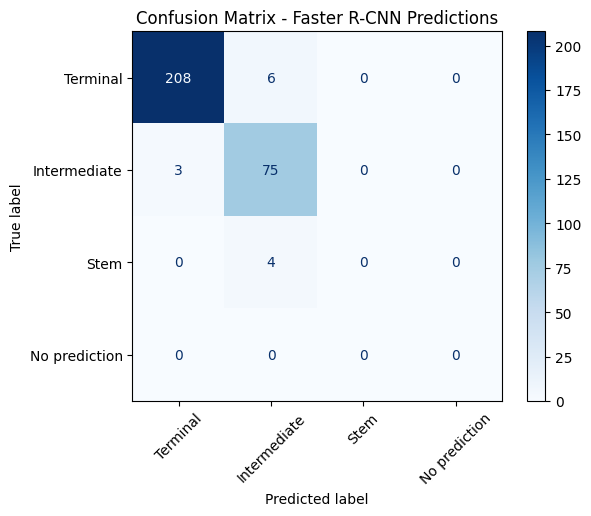

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Define confidence threshold
CONF_THRESH = 0.5

# Initialize prediction and ground-truth lists
y_true = []
y_pred = []

# Evaluate on test set
model.eval()
with torch.no_grad():
    for images, targets in test_loader:
        images = [img.to(device) for img in images]
        outputs = model(images)

        for output, target in zip(outputs, targets):
            # Get ground-truth label (assume only one object per image)
            true_label = target['labels'][0].item()
            y_true.append(true_label)

            # Get top prediction above threshold
            scores = output['scores'].cpu().numpy()
            labels = output['labels'].cpu().numpy()

            if len(scores) > 0 and max(scores) >= CONF_THRESH:
                best_idx = np.argmax(scores)
                y_pred.append(labels[best_idx])
            else:
                y_pred.append(-1)  # No prediction

# Create and display confusion matrix
labels = [1, 2, 3, -1]
label_names = ["Terminal", "Intermediate", "Stem", "No prediction"]

cm = confusion_matrix(y_true, y_pred, labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Confusion Matrix - Faster R-CNN Predictions")
plt.show()

In [ ]:
from sklearn.metrics import classification_report

# Define labels and class names (skip -1 for now)
labels = [1, 2, 3]
target_names = ["Terminal", "Intermediate", "Stem"]

# Print classification report
report = classification_report(y_true, y_pred, labels=labels, target_names=target_names, zero_division=0)
print(report)


              precision    recall  f1-score   support

    Terminal       0.99      0.97      0.98       214
Intermediate       0.88      0.96      0.92        78
        Stem       0.00      0.00      0.00         4

    accuracy                           0.96       296
   macro avg       0.62      0.64      0.63       296
weighted avg       0.95      0.96      0.95       296



- Faster Rcnn with metadata context

In [ ]:
zip_path = '/content/drive/MyDrive/resizedImages.zip'
import zipfile
import os

extract_path = '/content/data'  # Where to extract
os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

In [ ]:
import os

# Set path to extracted folder
extracted_dir = '/content/data/resizedImages'

# List first few image files
files = os.listdir(extracted_dir)
image_files = [f for f in files if f.endswith('.png')]

# Show count and a sample
print(f"Found {len(image_files)} image files.")
print("Sample files:", image_files[:5])

Found 1374 image files.
Sample files: ['Annotation_2244.png', 'Annotation_1717.png', 'Annotation_1232.png', 'Annotation_1977.png', 'Annotation_1547.png']


In [ ]:
import pandas as pd
import torch
from torch.utils.data import Dataset
from PIL import Image
import os
from torchvision import transforms

class FusedVilliDataset(Dataset):
    def __init__(self, image_dir, excel_path, transform=None):
        self.image_dir = image_dir
        self.df = pd.read_excel(excel_path)

        # Map class names to numeric labels
        self.label_map = {
            "Terminal villi": 0,
            "Intermediate villi": 1,
            "Stem villi": 2
        }

        self.transform = transform if transform else transforms.ToTensor()

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # Prepare image filename from annotation_id (e.g., "Annotation 2029" → "Annotation_2029.png")
        img_name = row["annotation_id"].replace(" ", "_") + ".png"
        img_path = os.path.join(self.image_dir, img_name)

        if not os.path.exists(img_path):
            raise FileNotFoundError(f"Image file not found: {img_path}")

        image = Image.open(img_path).convert("RGB")

        # Diameter as single-value tensor
        diameter = torch.tensor([float(row["diameter"])], dtype=torch.float32)

        # Convert class string to numeric label
        label = torch.tensor(self.label_map[row["class"]], dtype=torch.long)

        image = self.transform(image)

        return image, diameter, label, img_name

# === ✅ Verification Code ===

image_dir = "/content/data/resizedImages"
excel_path = "/content/drive/MyDrive/annotation_1_and_2_final_reshaped_combined.xlsx"

dataset = FusedVilliDataset(image_dir=image_dir, excel_path=excel_path)

# Print first 10 samples with checks
for i in range(10):
    img_tensor, diameter_tensor, label_tensor, _ = dataset[i]
    row = dataset.df.iloc[i]
    img_name = row["annotation_id"].replace(" ", "_") + ".png"
    class_name = row["class"]

    exists = os.path.exists(os.path.join(image_dir, img_name))

    print(f"[{i}] Image: {img_name} {'✅' if exists else '❌'}")
    print(f"     → Class: {class_name} → Label ID: {label_tensor.item()}")
    print(f"     → Diameter: {diameter_tensor.item():.2f}")
    print("-" * 50)

[0] Image: Annotation_10.png ✅
     → Class: Terminal villi → Label ID: 0
     → Diameter: 36.30
--------------------------------------------------
[1] Image: Annotation_12.png ✅
     → Class: Terminal villi → Label ID: 0
     → Diameter: 33.17
--------------------------------------------------
[2] Image: Annotation_13.png ✅
     → Class: Terminal villi → Label ID: 0
     → Diameter: 31.64
--------------------------------------------------
[3] Image: Annotation_14.png ✅
     → Class: Terminal villi → Label ID: 0
     → Diameter: 33.50
--------------------------------------------------
[4] Image: Annotation_16.png ✅
     → Class: Terminal villi → Label ID: 0
     → Diameter: 31.56
--------------------------------------------------
[5] Image: Annotation_17.png ✅
     → Class: Terminal villi → Label ID: 0
     → Diameter: 39.86
--------------------------------------------------
[6] Image: Annotation_18.png ✅
     → Class: Terminal villi → Label ID: 0
     → Diameter: 27.88
---------------

Split the dataset into train, val, test

In [ ]:
from torch.utils.data import random_split

# Define split lengths
total_size = len(dataset)
train_size = int(0.8 * total_size)
val_size = int(0.1 * total_size)
test_size = total_size - train_size - val_size  # ensure total sums up

# Split the dataset
train_dataset, val_dataset, test_dataset = random_split(dataset, [train_size, val_size, test_size])

print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")

Train: 970, Val: 121, Test: 122


Make the train, val, and test DataLoaders

In [ ]:
from torch.utils.data import DataLoader

batch_size = 16

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models

class VilliFusionModel(nn.Module):
    def __init__(self, num_classes=3):
        super(VilliFusionModel, self).__init__()

        # Load pretrained ResNet18 backbone
        self.backbone = models.resnet18(pretrained=True)
        self.backbone.fc = nn.Identity()  # remove final classification layer

        self.visual_dim = 512  # ResNet18 output
        self.metadata_dim = 1  # diameter input

        # Combine visual + metadata
        self.classifier = nn.Sequential(
            nn.Linear(self.visual_dim + self.metadata_dim, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, images, diameters):
        x = self.backbone(images)  # shape: [batch, 512]
        x = torch.cat((x, diameters), dim=1)  # concat diameter: [batch, 513]
        out = self.classifier(x)
        return out


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = VilliFusionModel(num_classes=3).to(device)


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [ ]:
import torch.nn as nn
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)


In [ ]:
num_epochs = 30

for epoch in range(num_epochs):
    # --- Training ---
    model.train()
    train_loss = 0.0
    print(f"\n🔁 Epoch [{epoch+1}/{num_epochs}]")

    for images, diameters, labels, img_names in train_loader:
        images = images.to(device)
        diameters = diameters.to(device)
        labels = labels.to(device)

        # 🖨️ Print each image name and diameter
        for name, dia in zip(img_names, diameters):
            print(f"📷 {name} → Diameter: {dia.item():.2f}")

        optimizer.zero_grad()
        outputs = model(images, diameters)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    avg_train_loss = train_loss / len(train_loader)

    # --- Validation ---
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, diameters, labels, img_names in val_loader:
            images = images.to(device)
            diameters = diameters.to(device)
            labels = labels.to(device)

            outputs = model(images, diameters)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    avg_val_loss = val_loss / len(val_loader)
    accuracy = 100 * correct / total

    print(f"✅ Train Loss: {avg_train_loss:.4f}")
    print(f"✅ Val Loss:   {avg_val_loss:.4f} | Accuracy: {accuracy:.2f}%")

Le flux de sortie a été tronqué et ne contient que les 5000 dernières lignes.
📷 Annotation_974.png → Diameter: 52.53
📷 Annotation_1381.png → Diameter: 71.06
📷 Annotation_870.png → Diameter: 34.03
📷 Annotation_1977.png → Diameter: 33.87
📷 Annotation_2149.png → Diameter: 49.68
📷 Annotation_2275.png → Diameter: 38.78
📷 Annotation_1776.png → Diameter: 59.66
📷 Annotation_1156.png → Diameter: 39.12
📷 Annotation_1666.png → Diameter: 51.89
📷 Annotation_810.png → Diameter: 34.82
📷 Annotation_1272.png → Diameter: 45.87
📷 Annotation_1876.png → Diameter: 63.65
📷 Annotation_2081.png → Diameter: 66.62
📷 Annotation_87.png → Diameter: 87.98
📷 Annotation_1339.png → Diameter: 193.20
📷 Annotation_1427.png → Diameter: 149.66
📷 Annotation_1797.png → Diameter: 50.39
📷 Annotation_1795.png → Diameter: 30.29
📷 Annotation_931.png → Diameter: 37.31
📷 Annotation_897.png → Diameter: 35.97
📷 Annotation_1684.png → Diameter: 44.47
📷 Annotation_869.png → Diameter: 48.89
📷 Annotation_837.png → Diameter: 47.20
📷 Annotat

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

y_true = []
y_pred = []

model.eval()
with torch.no_grad():
    for images, diameters, labels, _ in test_loader:
        images = images.to(device)
        diameters = diameters.to(device)
        labels = labels.to(device)

        outputs = model(images, diameters)
        _, predicted = torch.max(outputs.data, 1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())


📄 Classification Report:
              precision    recall  f1-score   support

    Terminal       0.96      0.97      0.96        88
Intermediate       0.91      0.88      0.89        33
        Stem       1.00      1.00      1.00         1

    accuracy                           0.94       122
   macro avg       0.95      0.95      0.95       122
weighted avg       0.94      0.94      0.94       122



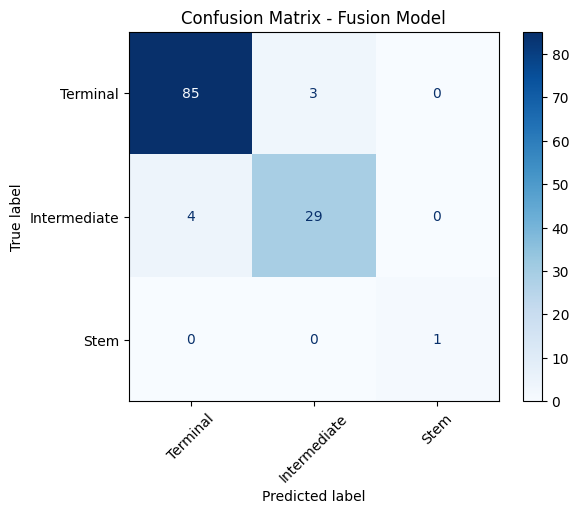

In [ ]:
target_names = ["Terminal", "Intermediate", "Stem"]

# Classification Report
print("📄 Classification Report:")
print(classification_report(y_true, y_pred, target_names=target_names, zero_division=0))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Confusion Matrix - Fusion Model")
plt.show()


In [ ]:
import os
import torch
import pandas as pd
from torchvision.transforms import ToPILImage
from PIL import Image, ImageDraw, ImageFont
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms

# --- Set up paths ---
image_dir = "/content/data/resizedImages"
excel_path = "/content/drive/MyDrive/annotation_1_and_2_final_reshaped_combined.xlsx"
output_dir = "/content/drive/MyDrive/fusion_outputs"
os.makedirs(output_dir, exist_ok=True)

# --- Load Excel metadata ---
df = pd.read_excel(excel_path)

# --- Build normalized metadata dictionary ---
id_to_meta = {
    row['annotation_id'].replace(" ", "").lower(): (row['class'], row['diameter'])
    for _, row in df.iterrows()
}

# --- Build a list of image names from the Excel file only ---
valid_images = [
    row['annotation_id'].replace(" ", "_") + ".png"
    for _, row in df.iterrows()
]

# --- Custom Dataset for Inference ---
class FusionTestDataset(Dataset):
    def __init__(self, image_dir, valid_images, id_to_meta):
        self.image_dir = image_dir
        self.images = valid_images
        self.transform = transforms.ToTensor()
        self.meta = id_to_meta

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        fname = self.images[idx]
        path = os.path.join(self.image_dir, fname)
        img = Image.open(path).convert("RGB")
        tensor = self.transform(img)

        base_name = os.path.splitext(fname)[0].replace("_", "").lower()
        cls, diameter = self.meta[base_name]

        return tensor, diameter, label, fname

# --- Load Dataset and DataLoader ---
test_dataset = FusionTestDataset(image_dir, valid_images, id_to_meta)
test_loader = DataLoader(test_dataset, batch_size=1)

# --- Inference and Annotation ---
model.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

label_map = {0: "Terminal", 1: "Intermediate", 2: "Stem"}

# Use a larger bold font
try:
    font_path = "/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf"
    font = ImageFont.truetype(font_path, size=32)
except:
    font = ImageFont.load_default()

for img_tensor, diameter, fname in test_loader:
    img_tensor = img_tensor.to(device)
    diameter_tensor = torch.tensor([[diameter]], dtype=torch.float32).to(device)

    with torch.no_grad():
        cls_out = model(img_tensor, diameter_tensor)

    pred_label = cls_out.argmax(dim=1).item()
    pred_class = label_map[pred_label]

    # Reconstruct and annotate image
    img = ToPILImage()(img_tensor.squeeze(0).cpu()).convert("RGB")
    draw = ImageDraw.Draw(img)
    draw.text((10, 10), f"Class: {pred_class}", font=font, fill="yellow")
    draw.text((10, 60), f"Diameter: {float(diameter):.2f}", font=font, fill="red")

    img.save(os.path.join(output_dir, fname[0]))

print("✅ All predictions saved to:", output_dir)

✅ All predictions saved to: /content/drive/MyDrive/fusion_outputs


Classification Report

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred, target_names=["Terminal", "Intermediate", "Stem"]))


              precision    recall  f1-score   support

    Terminal       0.96      0.97      0.96        88
Intermediate       0.91      0.88      0.89        33
        Stem       1.00      1.00      1.00         1

    accuracy                           0.94       122
   macro avg       0.95      0.95      0.95       122
weighted avg       0.94      0.94      0.94       122



Class Distribution

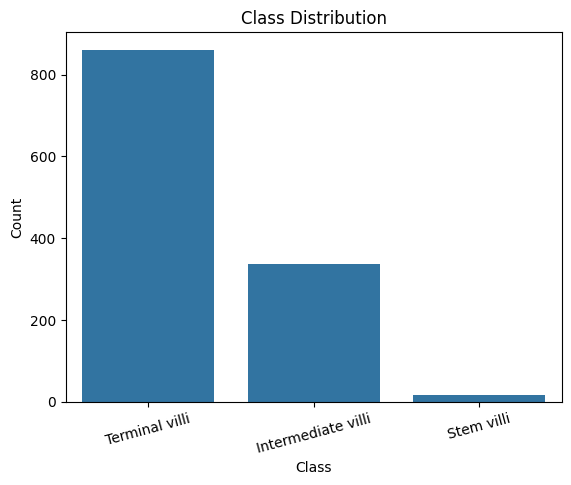

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x=df['class'])
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(rotation=15)
plt.show()


Diameter Distribution Per Class

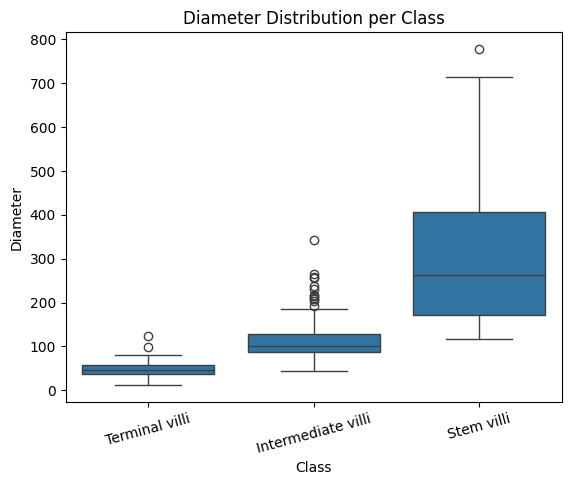

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(data=df, x="class", y="diameter")
plt.title("Diameter Distribution per Class")
plt.xlabel("Class")
plt.ylabel("Diameter")
plt.xticks(rotation=15)
plt.show()


Confidence Score Distribution (Histogram)

```
# Ce texte est au format code
```



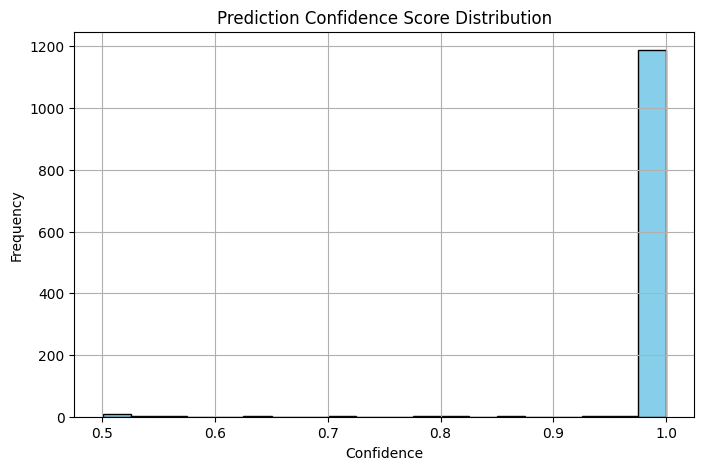

In [ ]:
import torch
import matplotlib.pyplot as plt

model.eval()
confidence_scores = []

with torch.no_grad():
    for batch in test_loader:
        images, diameters, _ = batch  # (you can ignore labels here)
        images = images.to(device)
        diameters = diameters.to(device).float().view(-1, 1)  # [B, 1]

        outputs = model(images, diameters)
        probs = torch.nn.functional.softmax(outputs, dim=1)
        top_confidence, _ = torch.max(probs, dim=1)  # Get top prediction confidence

        confidence_scores.extend(top_confidence.cpu().numpy())

# Plot the histogram
plt.figure(figsize=(8, 5))
plt.hist(confidence_scores, bins=20, color='skyblue', edgecolor='black')
plt.title("Prediction Confidence Score Distribution")
plt.xlabel("Confidence")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()


Per-Class Accuracy Plot

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

label_map = {0: "Terminal", 1: "Intermediate", 2: "Stem"}

y_true = []
y_pred = []

model.eval()
with torch.no_grad():
    for batch in test_loader:
        if len(batch) == 4:
            images, diameters, labels, _ = batch
        else:
            images, diameters, labels = batch

        images = images.to(device)
        diameters = diameters.to(device).view(-1, 1)
        labels = labels.to(device)

        outputs = model(images, diameters)
        _, predicted = torch.max(outputs, 1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)
per_class_acc = cm.diagonal() / cm.sum(axis=1)

# Plot
plt.figure(figsize=(6, 4))
bars = plt.bar(label_map.values(), per_class_acc, color='orange', edgecolor='black')
plt.title("Per-Class Accuracy")
plt.ylabel("Accuracy")
plt.ylim(0, 1.05)
plt.grid(True, axis='y')

# Annotate values
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.02, f"{yval:.2f}", ha='center', fontsize=12)

plt.show()


In [ ]:
print("y_true length:", len(y_true))
print("y_pred length:", len(y_pred))
print("Unique in y_true:", set(y_true))
print("Unique in y_pred:", set(y_pred))


y_true length: 0
y_pred length: 0
Unique in y_true: set()
Unique in y_pred: set()


In [ ]:
class FusionTestDataset(Dataset):
    def __init__(self, image_dir, valid_images, id_to_meta):
        self.image_dir = image_dir
        self.images = valid_images
        self.transform = transforms.ToTensor()
        self.meta = id_to_meta

        # ✅ Add class-to-index map
        self.label_map = {
            "Terminal villi": 0,
            "Intermediate villi": 1,
            "Stem villi": 2
        }

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        fname = self.images[idx]
        path = os.path.join(self.image_dir, fname)
        img = Image.open(path).convert("RGB")
        tensor = self.transform(img)

        base_name = os.path.splitext(fname)[0].replace("_", "").lower()
        cls, diameter = self.meta[base_name]

        label = self.label_map[cls]  # ✅ Convert class name to index

        return tensor, diameter, label, fname


# --- Load Dataset and DataLoader ---
test_dataset = FusionTestDataset(image_dir, valid_images, id_to_meta)
test_loader = DataLoader(test_dataset, batch_size=1)
# we added labels to test loader we avoided adding it in the same previous block to avoid any problems that can arise and disturb our already obtained results

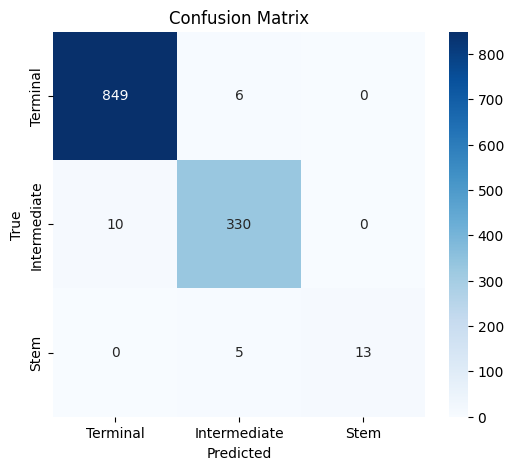

In [ ]:
import torch
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

label_map = {0: "Terminal", 1: "Intermediate", 2: "Stem"}

y_true = []
y_pred = []

model.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

with torch.no_grad():
    for images, diameters, labels, _ in test_loader:
        images = images.to(device)
        diameters = diameters.to(dtype=torch.float32).to(device).view(-1, 1)
        labels = labels.to(device)

        outputs = model(images, diameters)
        _, predicted = torch.max(outputs, 1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

# ✅ Plot confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=label_map.values(), yticklabels=label_map.values())
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()
